## Preprocessing

### Group 30

### Imports and General Setup

In [1]:
# Bibliothèques de base
import os
import warnings

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Outils de machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Pour plus tard : modèles de régression (exemples)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Configuration affichage
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid")

print("Imports OK.")


Imports OK.


### Step 1 – Dataset Loading and Initial Exploration

In [2]:
import pandas as pd

# Replace this path with the actual file path on your side
data_path = "X_train.csv"

# Load the dataset
df = pd.read_csv(data_path)

# Shape of the dataset
print(f"Dataset shape: {df.shape}")  # (rows, columns)

# List of columns and their types
print("\nColumn Info:")
print(df.dtypes)

# Display the first 5 rows
print("\nFirst 5 rows:")
display(df.head())

# Quick summary of missing values
print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(10))  # top 10

# Basic statistics
print("\nDescriptive statistics (numeric):")
display(df.describe())


Dataset shape: (1172086, 307)

Column Info:
Unnamed: 0                    int64
Year                          int64
CNT                          object
CNTRYID                     float64
CNTSCHID                    float64
                             ...   
science_q15_total_timing    float64
science_q16_total_timing    float64
science_q17_total_timing    float64
science_q18_total_timing    float64
science_q19_total_timing    float64
Length: 307, dtype: object

First 5 rows:


,Unnamed: 0,Year,CNT,CNTRYID,CNTSCHID,CNTSTUID,CYC,NatCen,STRATUM,SUBNATIO,OECD,ADMINMODE,LANGTEST_QQQ,LANGTEST_COG,LANGTEST_PAQ,Option_CT,Option_FL,Option_ICTQ,Option_WBQ,Option_PQ,Option_TQ,Option_UH,ST001D01T,ST003D02T,ST003D03T,ST004D01T,EFFORT1,EFFORT2,OCOD1,OCOD2,OCOD3,AGE,GRADE,ISCEDP,IMMIG,COBN_S,MISSSC,MATHEASE,WB153,ST253,ST311,WB165,IC171,ST038,IC180,ST255,ST350,ST034,FL162,PA195,...,reading_q6_total_timing,reading_q7_total_timing,reading_q8_total_timing,reading_q9_total_timing,reading_q10_total_timing,reading_q11_total_timing,reading_q12_total_timing,reading_q13_total_timing,reading_q14_total_timing,reading_q15_total_timing,math_q1_total_timing,math_q2_total_timing,math_q3_total_timing,math_q4_total_timing,math_q5_total_timing,math_q6_total_timing,math_q7_total_timing,math_q8_total_timing,math_q9_total_timing,math_q10_total_timing,math_q11_total_timing,math_q12_total_timing,math_q13_total_timing,math_q14_total_timing,math_q15_total_timing,math_q16_total_timing,math_q17_total_timing,math_q18_total_timing,math_q19_total_timing,math_q20_total_timing,math_q21_total_timing,science_q1_total_timing,science_q2_total_timing,science_q3_total_timing,science_q4_total_timing,science_q5_total_timing,science_q6_total_timing,science_q7_total_timing,science_q8_total_timing,science_q9_total_timing,science_q10_total_timing,science_q11_total_timing,science_q12_total_timing,science_q13_total_timing,science_q14_total_timing,science_q15_total_timing,science_q16_total_timing,science_q17_total_timing,science_q18_total_timing,science_q19_total_timing
0,384002,2022,NLD,528.0,52800132.0,52801144.0,08MS,52800,NLD06,5280000,1.0,2.0,322.0,322.0,NaN,1.0,1.0,0.0,1.0,0.0,0.0,1.0,10.0,2.0,2007.0,1.0,8.0,8.0,3256.0,2212.0,9999.0,15.75,0.0,244.0,2.0,52800.0,0.0,0.0,2.5,1.0,3.25,1.0,0.0,0.0,0.0,0.666667,0.0,2.333333,3.666667,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18736.0,23055.25,162720.00,110641.333333,96368.333333,71813.5,98875.000000,63689.400000,37232.000000,88274.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84299.333333,90156.000000,66612.00,73547.6,68912.000000,56623.250000,104190.500000,132623.25,105785.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1118072,2018,QAZ,31.0,3100106.0,3100424.0,07MS,3100,QAZ0101,310000,0.0,2.0,803.0,803.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,11.0,2002.0,2.0,7.0,6.0,2330.0,9313.0,0.0,15.42,0.0,NaN,NaN,3100.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0.200000,NaN,2.000000,NaN,NaN,...,8368.284180,112711.000000,69975.710938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50234.0,80788.00,48059.00,116718.000000,61003.000000,34117.0,56901.667969,76615.000000,21500.333984,27087.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,845454,2018,FRA,250.0,25000010.0,25005207.0,07MS,25000,FRA0101,2500000,1.0,2.0,493.0,493.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,5.0,2002.0,1.0,NaN,NaN,3323.0,3322.0,7512.0,16.00,0.0,NaN,NaN,25000.0,NaN,NaN,NaN,NaN,NaN,0.0,3.5,0.0,NaN,0.600000,NaN,2.000000,NaN,NaN,...,39792.332031,92942.984375,82727.664062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81443.664062,190243.406250,36257.00,148073.5,2121.249756,90540.335938,57954.000000,84633.00,45332.000000,87686.5,13164.75,1187.199951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1728613,2015,QES,971.0,97100240.0,97127584.0,06MS,72400,ESP1633,7241600,2.0,2.0,156.0,156.0,NaN,NaN,1.0,1.0,NaN,1.0,1.0,0.0,10.0,3.0,1999.0,2.0,NaN,NaN,NaN,NaN,NaN,16.17,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,114817.335938,81293.335938,59014.332031,140646.328125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62224.667969,83289.664062,91510.75,100649.5,82378.500000,74348.250000,91230.664062,49789.00,37855.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1083243,2018,PHL,608.0,60800071.0,60802698.0,07MS,60800,PHL0011,6080000,0.0,2.0,313.0,313.0,NaN,NaN,NaN,NaN,NaN,N


Missing values per column:
math_q18_average_score       1172086
math_q19_average_score       1172086
math_q20_average_score       1172086
math_q21_average_score       1172086
math_q21_total_timing        1172086
science_q19_total_timing     1172085
math_q18_total_timing        1172085
math_q17_average_score       1172085
science_q13_average_score    1172085
science_q14_average_score    1172085
dtype: int64

Descriptive statistics (numeric):


,Unnamed: 0,Year,CNTRYID,CNTSCHID,CNTSTUID,NatCen,SUBNATIO,OECD,ADMINMODE,LANGTEST_QQQ,LANGTEST_COG,LANGTEST_PAQ,Option_CT,Option_FL,Option_ICTQ,Option_WBQ,Option_PQ,Option_TQ,Option_UH,ST001D01T,ST003D02T,ST003D03T,ST004D01T,EFFORT1,EFFORT2,OCOD1,OCOD2,OCOD3,AGE,GRADE,ISCEDP,IMMIG,COBN_S,MISSSC,MATHEASE,WB153,ST253,ST311,WB165,IC171,ST038,IC180,ST255,ST350,ST034,FL162,PA195,ST330,FL169,ST230,...,reading_q6_total_timing,reading_q7_total_timing,reading_q8_total_timing,reading_q9_total_timing,reading_q10_total_timing,reading_q11_total_timing,reading_q12_total_timing,reading_q13_total_timing,reading_q14_total_timing,reading_q15_total_timing,math_q1_total_timing,math_q2_total_timing,math_q3_total_timing,math_q4_total_timing,math_q5_total_timing,math_q6_total_timing,math_q7_total_timing,math_q8_total_timing,math_q9_total_timing,math_q10_total_timing,math_q11_total_timing,math_q12_total_timing,math_q13_total_timing,math_q14_total_timing,math_q15_total_timing,math_q16_total_timing,math_q17_total_timing,math_q18_total_timing,math_q19_total_timing,math_q20_total_timing,math_q21_total_timing,science_q1_total_timing,science_q2_total_timing,science_q3_total_timing,science_q4_total_timing,science_q5_total_timing,science_q6_total_timing,science_q7_total_timing,science_q8_total_timing,science_q9_total_timing,science_q10_total_timing,science_q11_total_timing,science_q12_total_timing,science_q13_total_timing,science_q14_total_timing,science_q15_total_timing,science_q16_total_timing,science_q17_total_timing,science_q18_total_timing,science_q19_total_timing
count,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.172086e+06,1.156728e+06,1.172086e+06,190244.000000,412647.000000,760766.000000,760766.000000,412647.000000,760766.000000,760766.000000,760766.000000,1.172086e+06,1.140384e+06,1.156567e+06,1.172037e+06,690553.000000,684199.000000,823967.000000,823967.000000,823967.000000,1.168818e+06,805483.000000,412645.000000,710868.000000,823967.000000,350864.000000,340810.000000,412647.000000,412647.000000,412647.000000,823967.000000,823967.000000,823967.000000,412647.000000,823967.000000,412647.000000,823967.000000,412647.000000,412647.000000,412647.000000,412647.000000,412647.000000,...,6.030370e+05,5.304950e+05,3.366750e+05,1.005430e+05,941.000000,139.000000,73.000000,41.000000,12.000000,3.000000,6.793450e+05,6.787310e+05,6.774830e+05,6.711490e+05,6.583870e+05,6.414750e+05,6.306690e+05,6.086540e+05,5.868940e+05,5.185320e+05,4.408200e+05,3.038110e+05,1.824880e+05,8.817100e+04,3.489300e+04,2.295600e+04,1.0,1.0,1.000000,1.0,0.0,6.426680e+05,6.422500e+05,6.411090e+05,6.387540e+05,6.294370e+05,6.110490e+05,5.861210e+05,5.553690e+05,4.431870e+05,3.307340e+05,2.221060e+05,4.514500e+04,1.000000,1.0,1.0,1.0,1.00,1.000000,1.00
mean,8.788127e+05,2.018517e+03,4.494376e+02,4.494433e+07,4.492926e+07,4.321244e+04,4.437437e+06,5.213278e-01,1.912332e+00,3.136003e+02,3.139330e+02,252.481324,0.814413,0.327858,0.669643,0.219485,0.228988,0.300092,0.160316,1.141946e+01,6.571160e+00,2.002591e+03,1.500241e+00,7.824746,9.029611,5866.949590,5759.624446,5031.857720,1.579184e+01,-0.139855,312.920685,1.179683,118399.332157,0.101891,0.103615,0.420411,0.726139,2.309725,0.086288,1.846118,0.670083,2.083616,0.388077,0.148537,2.313571,0.681207,0.061641,1.328697,1.358509,0.576880,...,4.923457e+04,6.144251e+04,6.423997e+04,6.849181e+04,53477.077612,30183.621353,32525.305947,30055.001529,43336.649398,11198.571115,9.256004e+04,8.446210e+04,9.225280e+04,9.382821e+04,9.449319e+04,1.021636e+05,1.001498e+05,9.681770e+04,9.239146e+04,9.136022e+04,9.005534e+04,8.965285e+04,8.686860e+04,8.355656e+04,8.575860e+04,1.017054e+05,13121.0,4799.0,34486.333333,19540.0,NaN,7.175243e+04,7.771194e+04,7.969735e+04,7.647816e+04,6.886065e+04,6.847547e+04,6.560120e+04,6.890748e+04,6.574302e+04,6.442787e+04,6.821547e+04,4.255167e+04,73159.335938,47928.5,53570.5,118881.0,119068.25,167551.796875,59299.25
std,5.075340e+05,2.835234e+00,2.729180e+02,2.729202e

### Column Overview

In [4]:
# Aperçu des noms de colonnes
print("Total columns:", len(df.columns))
print("\ncolumn names:")
print(df.columns.tolist())

# Séparation colonnes numériques / catégorielles
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"\nNumeric columns: {len(num_cols)}")
print(num_cols[:10])  # aperçu

print(f"\nCategorical columns: {len(cat_cols)}")
print(cat_cols[:10])  # aperçu


Total columns: 307

column names:
['Unnamed: 0', 'Year', 'CNT', 'CNTRYID', 'CNTSCHID', 'CNTSTUID', 'CYC', 'NatCen', 'STRATUM', 'SUBNATIO', 'OECD', 'ADMINMODE', 'LANGTEST_QQQ', 'LANGTEST_COG', 'LANGTEST_PAQ', 'Option_CT', 'Option_FL', 'Option_ICTQ', 'Option_WBQ', 'Option_PQ', 'Option_TQ', 'Option_UH', 'ST001D01T', 'ST003D02T', 'ST003D03T', 'ST004D01T', 'EFFORT1', 'EFFORT2', 'OCOD1', 'OCOD2', 'OCOD3', 'AGE', 'GRADE', 'ISCEDP', 'IMMIG', 'COBN_S', 'MISSSC', 'MATHEASE', 'WB153', 'ST253', 'ST311', 'WB165', 'IC171', 'ST038', 'IC180', 'ST255', 'ST350', 'ST034', 'FL162', 'PA195', 'ST330', 'FL169', 'ST230', 'ST331', 'ST354', 'PA042', 'ST305', 'ST258', 'PA167', 'IC176', 'ST352', 'IC173', 'PA188', 'ST283', 'ST256', 'WB154', 'WB166', 'FL150', 'ST266', 'IC174', 'ST005', 'ST021', 'IC182', 'FL164', 'FL160', 'ST267', 'ST338', 'ST351', 'ST342', 'ST355', 'FL166', 'PA183', 'ST007', 'FL170', 'WB168', 'WB163', 'IC184', 'ST348', 'ST226', 'ST336', 'WB160', 'FL167', 'PA166', 'ST250', 'ST268', 'IC177', 'PA196',

### Missing Values Analysis

In [5]:
# Pourcentage de valeurs manquantes par colonne
missing_ratio = df.isnull().mean().sort_values(ascending=False)

# Affichage des colonnes les plus concernées
missing_cols = missing_ratio[missing_ratio > 0.0]
print(f"Columns with missing values: {len(missing_cols)}")

display(missing_cols.head(50))

Columns with missing values: 293


math_q18_average_score       1.000000
math_q19_average_score       1.000000
math_q20_average_score       1.000000
math_q21_average_score       1.000000
math_q21_total_timing        1.000000
science_q19_total_timing     0.999999
math_q18_total_timing        0.999999
math_q17_average_score       0.999999
science_q13_average_score    0.999999
science_q14_average_score    0.999999
science_q15_average_score    0.999999
science_q17_average_score    0.999999
science_q18_average_score    0.999999
science_q19_average_score    0.999999
math_q17_total_timing        0.999999
science_q16_average_score    0.999999
math_q19_total_timing        0.999999
science_q16_total_timing     0.999999
science_q14_total_timing     0.999999
science_q17_total_timing     0.999999
science_q13_total_timing     0.999999
science_q18_total_timing     0.999999
math_q20_total_timing        0.999999
science_q15_total_timing     0.999999
reading_q15_average_score    0.999998
reading_q15_total_timing     0.999997
reading_q14_

### Dropping Columns with Too Many Missing Values


In [6]:
# Drop columns with >90% missing values
high_missing_cols = missing_ratio[missing_ratio > 0.5].index.tolist()

print(f"Number of columns to drop: {len(high_missing_cols)}")

# Option 1: Drop
df_cleaned = df.drop(columns=high_missing_cols)

# Option 2 (Alternative): Save them separately if needed
# df_high_missing = df[high_missing_cols]

# New shape after removal
print("Shape after dropping high-missing columns:", df_cleaned.shape)


Number of columns to drop: 206
Shape after dropping high-missing columns: (1172086, 101)


### Data Types Analysis

In [7]:
# Overview of data types
dtype_counts = df.dtypes.value_counts()
print("Data type distribution:")
display(dtype_counts)

# Show object columns (potential categoricals or misclassified numerics)
object_cols = df.select_dtypes(include='object').columns
print(f"\nNumber of 'object' columns: {len(object_cols)}")
display(object_cols)

# Look at unique value counts in object columns (to detect categorical candidates)
for col in object_cols:
    unique_vals = df[col].nunique(dropna=True)
    if unique_vals < 30:
        print(f" Categorical candidate: {col} ({unique_vals} unique values)")
    else:
        print(f" Non-categorical or needs inspection: {col} ({unique_vals} unique values)")


Data type distribution:


float64    300
int64        4
object       3
Name: count, dtype: int64


Number of 'object' columns: 3


Index(['CNT', 'CYC', 'STRATUM'], dtype='object')

 Non-categorical or needs inspection: CNT (98 unique values)
 Categorical candidate: CYC (3 unique values)
 Non-categorical or needs inspection: STRATUM (2731 unique values)


### Number of remaining columns

In [8]:
# Overview of column names and types in the cleaned dataset
print("Total columns:", len(df_cleaned.columns))

print("\nColumn names:")
print(df_cleaned.columns.tolist())

# Split into numerical and categorical columns
num_cols = df_cleaned.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df_cleaned.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"\nNumber of numerical columns: {len(num_cols)}")
print(num_cols[:10])  # preview

print(f"\nNumber of categorical columns: {len(cat_cols)}")
print(cat_cols[:10])  # preview


Total columns: 101

Column names:
['Unnamed: 0', 'Year', 'CNT', 'CNTRYID', 'CNTSCHID', 'CNTSTUID', 'CYC', 'NatCen', 'STRATUM', 'SUBNATIO', 'OECD', 'ADMINMODE', 'LANGTEST_QQQ', 'LANGTEST_COG', 'Option_FL', 'Option_ICTQ', 'Option_PQ', 'Option_TQ', 'Option_UH', 'ST001D01T', 'ST003D02T', 'ST003D03T', 'ST004D01T', 'EFFORT1', 'EFFORT2', 'OCOD1', 'OCOD2', 'OCOD3', 'AGE', 'GRADE', 'IMMIG', 'COBN_S', 'WB165', 'IC171', 'ST038', 'ST255', 'ST034', 'PA042', 'IC173', 'WB154', 'IC174', 'ST005', 'ST021', 'PA183', 'ST007', 'WB163', 'PA166', 'ST250', 'ST296', 'ST270', 'ST353', 'ST349', 'WB164', 'ST062', 'ST254', 'IC170', 'reading_q1_average_score', 'reading_q2_average_score', 'reading_q3_average_score', 'reading_q4_average_score', 'reading_q5_average_score', 'reading_q6_average_score', 'math_q1_average_score', 'math_q2_average_score', 'math_q3_average_score', 'math_q4_average_score', 'math_q5_average_score', 'math_q6_average_score', 'math_q7_average_score', 'math_q8_average_score', 'math_q9_average_scor

### Imputing Missing Values with Column Mean

In [9]:
# Impute missing values with column means (numerical only)
df_cleaned = df_cleaned.copy()  # create a safe copy

# Only apply mean imputation on numerical columns
num_cols = df_cleaned.select_dtypes(include=["float64", "int64"]).columns

df_cleaned[num_cols] = df_cleaned[num_cols].fillna(df_cleaned[num_cols].mean())

# Confirm remaining missing values
missing_total = df_cleaned.isnull().sum().sum()
print(f"Remaining missing values: {missing_total}")


Remaining missing values: 0


### Outlier Detection and Exploration

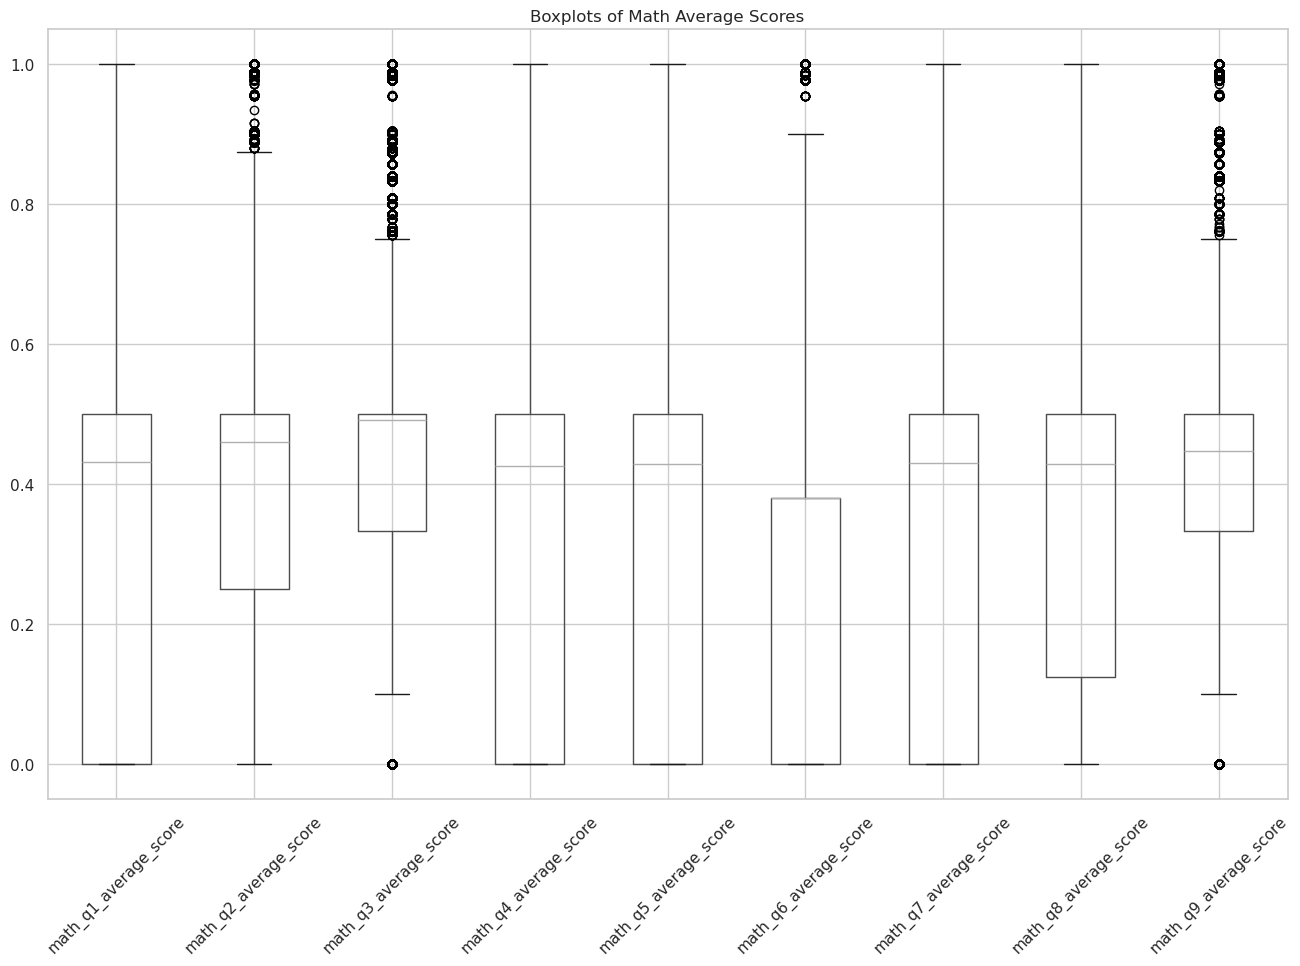

In [11]:
# Sélection des colonnes mathématiques avec "average_score"
math_score_cols = [col for col in df_cleaned.columns if "math" in col and "average_score" in col]

# Affichage de boxplots pour voir les éventuels outliers
plt.figure(figsize=(16, 10))
df_cleaned[math_score_cols].boxplot()
plt.title("Boxplots of Math Average Scores")
plt.xticks(rotation=45)
plt.show()


### Nettoyage des colonnes catégorielles

### Standardiser les chaînes de caractères

In [12]:
# On repart de df_cleaned
df_cat_cleaned = df_cleaned.copy()

# Standardiser les colonnes catégorielles : strip, lowercase
for col in df_cat_cleaned.select_dtypes(include=["object", "category"]).columns:
    df_cat_cleaned[col] = df_cat_cleaned[col].astype(str).str.strip().str.lower()

print("Standardisation terminée.")


Standardisation terminée.


### Visualiser la cardinalité de chaque colonne

In [14]:
# Aperçu des colonnes avec leur nombre de catégories uniques
cat_cols = df_cat_cleaned.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    print(f"{col}: {df_cat_cleaned[col].nunique()} unique values")


CNT: 98 unique values
CYC: 3 unique values
STRATUM: 2731 unique values


### Détecter et regrouper les catégories rares

In [17]:
# Fonction pour regrouper les catégories rares en "other"
def group_rare_categories(df, col, threshold=0.01):
    freq = df[col].value_counts(normalize=True)
    rare_labels = freq[freq < threshold].index
    df[col] = df[col].apply(lambda x: "other" if x in rare_labels else x)
    return df

# Application sur toutes les colonnes catégorielles
for col in cat_cols:
    df_cat_cleaned = group_rare_categories(df_cat_cleaned, col)

print("Rare categories regrouped as 'other'.")


Rare categories regrouped as 'other'.


## Step 4 – Feature Engineering (Part 1): Skewness Analysis and Log Transformation

In this step, we explore and transform highly skewed numerical features.

- Skewed features can negatively impact model performance.
- A log transformation can help normalize the distribution of such features.
- We only apply log(1+x) to positively skewed features to preserve interpretability.

We start by calculating the skewness for each numerical column and then apply log transformation to those with skewness > 1.


In [19]:
from scipy.stats import skew

# Select numeric columns
num_cols = df_cat_cleaned.select_dtypes(include=["float64", "int64"]).columns

# Compute skewness
skewed_feats = df_cat_cleaned[num_cols].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

# Display top 10 most skewed features
print("Top 10 skewed features:")
display(skewed_feats.head(10))


Top 10 skewed features:


math_q9_total_timing       537.291206
math_q6_total_timing       506.412896
science_q7_total_timing    281.967717
reading_q2_total_timing    273.637728
math_q5_total_timing       268.962176
math_q1_total_timing       261.666154
math_q3_total_timing       192.468263
science_q3_total_timing    139.723256
math_q2_total_timing       129.444188
reading_q1_total_timing    114.433815
dtype: float64

## Log Transformation on Highly Skewed Features

We apply a log(1+x) transformation on features with a skewness greater than 1.

This will help reduce the skewness and make the data more normally distributed, which improves the performance of models sensitive to feature distributions.


In [20]:
# Identify skewed features with skewness > 1
skewed_features = skewed_feats[skewed_feats > 1].index

# Make a copy of the cleaned dataframe
df_transformed = df_cat_cleaned.copy()

# Apply log1p (log(1 + x)) transformation
df_transformed[skewed_features] = df_transformed[skewed_features].apply(lambda x: np.log1p(x))

print(f"Log transformation applied to {len(skewed_features)} features.")


Log transformation applied to 47 features.


### Feature Selection

In [24]:
from sklearn.feature_selection import VarianceThreshold

# Filter only numeric columns before applying VarianceThreshold
numeric_df = df_transformed.select_dtypes(include=["int64", "float64"])

# Step 1: Remove constant and quasi-constant features
selector = VarianceThreshold(threshold=0.01)
selector.fit(numeric_df)

# Get columns to keep
features_to_keep = numeric_df.columns[selector.get_support()]
print(f"Remaining features after removing constant/quasi-constant: {len(features_to_keep)}")

# Update the dataframe
df_final = df_transformed[features_to_keep]

# Final shape
print(f"Final shape of the dataset after feature selection: {df_final.shape}")


Remaining features after removing constant/quasi-constant: 96
Final shape of the dataset after feature selection: (1172086, 96)


###  Target Construction – Creating the `MathScore` Column

To predict students' overall math performance, we create a new target variable called `MathScore`.  
The dataset includes individual average scores for several math-related questions (e.g., `math_q1_average_score`, `math_q2_average_score`, ...).

Instead of selecting just one question or working with multiple targets, we compute the **row-wise average** of all math question scores.  
This gives us a single, interpretable, and robust target to train our regression models on.

Note: We will consider dropping the original question-level score columns to avoid data leakage later in the pipeline.


In [25]:
# Identify columns with math average scores
math_score_cols = [col for col in df_final.columns if col.startswith('math_q') and 'average_score' in col]

# Create a new column as the row-wise average of math question scores
df_final['MathScore'] = df_final[math_score_cols].mean(axis=1)

# Optional: drop original question columns to avoid leakage
# df_final = df_final.drop(columns=math_score_cols)

print(f"New target column 'MathScore' created using {len(math_score_cols)} question scores.")
display(df_final[['MathScore']].describe())


New target column 'MathScore' created using 9 question scores.


,MathScore
count,1.172086e+06
mean,4.365648e-01
std,1.672929e-01
min,0.000000e+00
25%,3.611111e-01
50%,4.365648e-01
75%,4.759259e-01
max,1.000000e+00


### Correlation Analysis

Now that we have a unified target variable `MathScore`, we proceed to analyze the correlation between this target and the input features.

This helps us:
- Understand which variables are most predictive of math performance.
- Detect multicollinearity between features.
- Optionally drop highly correlated variables (if redundant).

We will:
- Compute Pearson correlation.
- Visualize the correlation matrix (heatmap).
- Plot top 20 features most correlated with `MathScore`.


Top 20 features correlated with MathScore:


math_q1_average_score       0.555734
math_q2_average_score       0.541760
math_q3_average_score       0.530898
math_q8_average_score       0.508984
math_q9_average_score       0.500351
math_q4_average_score       0.496186
math_q7_average_score       0.490743
math_q6_average_score       0.469810
math_q5_average_score       0.453373
ST255                       0.244731
math_q2_total_timing        0.196515
math_q7_total_timing        0.188744
math_q6_total_timing        0.188439
math_q1_total_timing        0.186790
math_q3_total_timing        0.186387
OECD                        0.178795
math_q4_total_timing        0.176995
science_q6_average_score    0.176953
math_q5_total_timing        0.174259
OCOD1                      -0.191268
dtype: float64

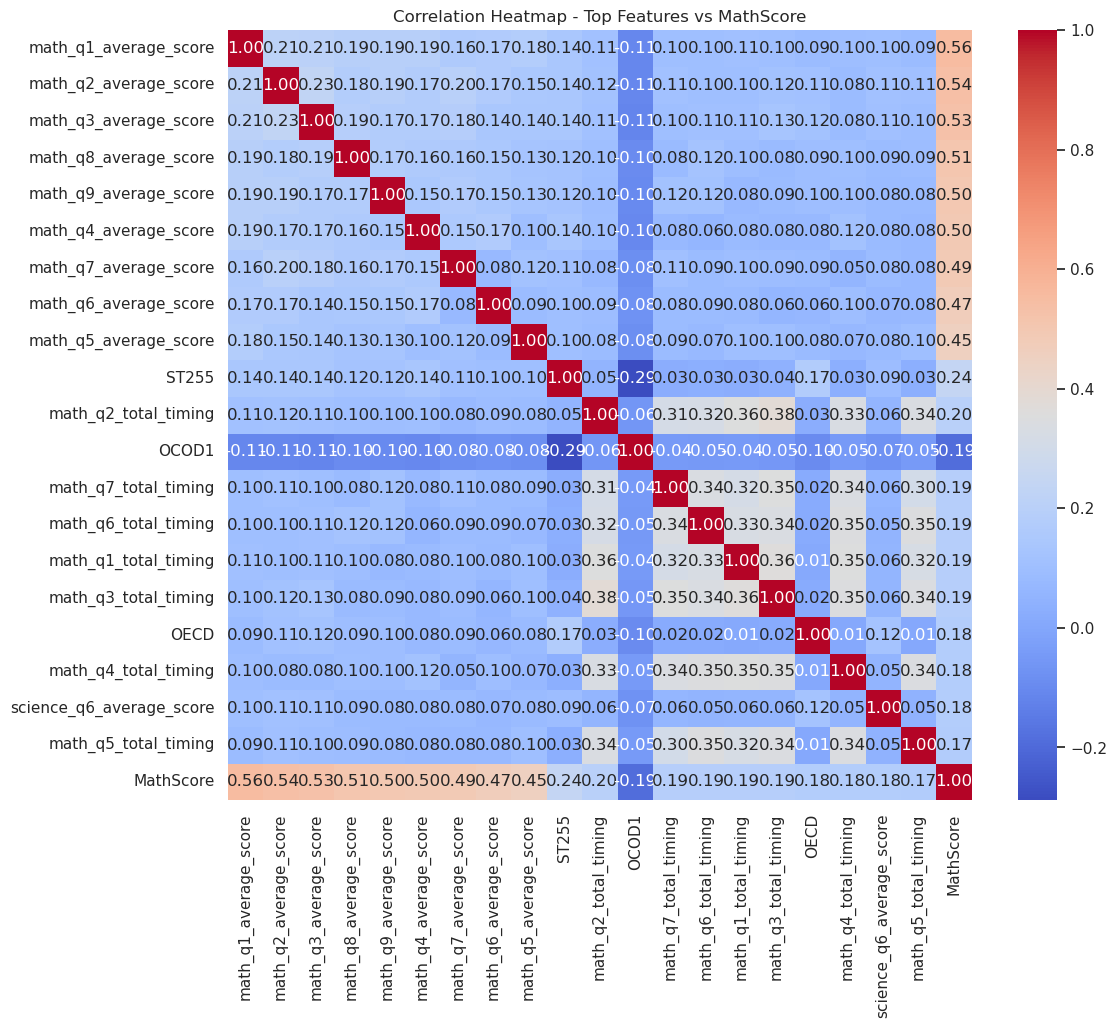

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df_final.corr()

# Extract correlation with target
target_corr = corr_matrix["MathScore"].drop("MathScore")

# Display top 20 most correlated features (positive or negative)
top_corr = target_corr.abs().sort_values(ascending=False).head(20)
print("Top 20 features correlated with MathScore:")
display(df_final[top_corr.index].corrwith(df_final["MathScore"]).sort_values(ascending=False))

# Plot heatmap of top correlations
plt.figure(figsize=(12, 10))
sns.heatmap(df_final[top_corr.index.tolist() + ["MathScore"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - Top Features vs MathScore")
plt.show()


### Principal Component Analysis (PCA) – Optional Step

If we observe:
- Strong multicollinearity between features
- A very large number of features that may affect model generalization

We may apply **PCA** (Principal Component Analysis) to:
- Reduce the number of features
- Preserve maximum variance
- Speed up model training

We will standardize the data before applying PCA and plot the explained variance ratio.


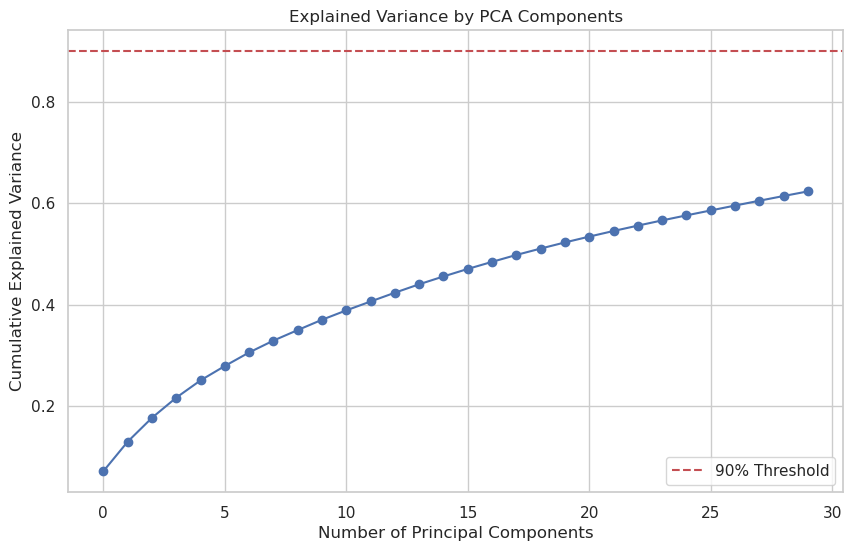

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Drop target before PCA
X = df_final.drop("MathScore", axis=1)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=30)  # Arbitrary number to see how much variance is explained
X_pca = pca.fit_transform(X_scaled)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.axhline(0.90, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.show()


## Step 9 – Smart Train-Test Split

We now split our dataset into training and testing sets to evaluate model performance.  
Key considerations:

- We use stratified sampling if the target is categorical to ensure class balance.
- In our case, since `MathScore` is continuous (regression task), we will perform a standard split.
- We'll reserve 20% of the data for testing.

This step is essential to ensure fair evaluation of the model's performance on unseen data.


In [28]:
from sklearn.model_selection import train_test_split

# Define the target variable
target = 'MathScore'

# Separate features and target
X = df_final.drop(columns=[target])
y = df_final[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test split completed.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Train/Test split completed.
X_train shape: (937668, 96)
X_test shape: (234418, 96)
y_train shape: (937668,)
y_test shape: (234418,)


## Step 10 – Linear Regression Model

We start with a basic Linear Regression model as a benchmark.

Linear regression assumes a linear relationship between input features and the target `MathScore`. It is interpretable but may underperform on non-linear problems.

We'll fit the model and evaluate it using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize and train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("🔍 Linear Regression Results:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


🔍 Linear Regression Results:
MAE  : 0.0000
MSE  : 0.0000
RMSE : 0.0000
R²   : 1.0000


In [30]:
'MathScore' in X_train.columns


False

In [31]:
# Remove MathScore if it's in the features
if 'MathScore' in X_train.columns:
    X_train = X_train.drop(columns=['MathScore'])
    X_test = X_test.drop(columns=['MathScore'])
